In [1]:
!pip install yfinance

In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
data = yf.download("AAPL", start = "2021-01-01", end = "2026-01-01")

[*********************100%***********************]  1 of 1 completed


In [4]:
data.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2021-01-04,125.632484,129.709882,123.059837,129.622513,143301900
2021-01-05,127.185783,127.894485,124.681092,125.127671,97664900
2021-01-06,122.904510,127.224618,122.690931,123.991820,155088000
2021-01-07,127.098412,127.787693,124.127736,124.613141,109578200
2021-01-08,128.195450,128.758521,126.428569,128.564348,105158200


In [5]:
data.columns = data.columns.get_level_values(0)
data.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2021-01-04,125.632484,129.709882,123.059837,129.622513,143301900
2021-01-05,127.185783,127.894485,124.681092,125.127671,97664900
2021-01-06,122.904510,127.224618,122.690931,123.991820,155088000
2021-01-07,127.098412,127.787693,124.127736,124.613141,109578200
2021-01-08,128.195450,128.758521,126.428569,128.564348,105158200


In [6]:
print(data.shape)
data.info()

(1255, 5)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1255 entries, 2021-01-04 to 2025-12-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1255 non-null   float64
 1   High    1255 non-null   float64
 2   Low     1255 non-null   float64
 3   Open    1255 non-null   float64
 4   Volume  1255 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 58.8 KB


In [7]:
data.isnull().sum()

Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [8]:
data.duplicated().sum()

0

In [9]:
data.describe()

Price,Close,High,Low,Open,Volume
count,1255.000000,1255.000000,1255.000000,1255.000000,1.255000e+03
mean,179.053880,180.815821,177.115773,178.876145,6.981550e+07
std,39.983622,40.208191,39.702015,39.935372,2.996296e+07
min,113.132225,117.060166,112.986384,115.728149,1.791060e+07
25%,145.694473,147.344710,144.250317,145.516956,4.834280e+07
50%,171.215561,172.746126,169.349988,171.046510,6.313550e+07
75%,210.134407,212.197254,207.535183,209.557202,8.453615e+07
max,285.413116,287.836529,282.530963,285.423116,3.186799e+08


In [10]:
data["Daily_Change"] = data["Close"] - data["Open"]

In [11]:
data["Pct_Change"] = data["Close"].pct_change()*100

In [12]:
data.head()

Price,Close,High,Low,Open,Volume,Daily_Change,Pct_Change
Date,,,,,,,
2021-01-04,125.632484,129.709882,123.059837,129.622513,143301900,-3.990028,NaN
2021-01-05,127.185783,127.894485,124.681092,125.127671,97664900,2.058112,1.236383
2021-01-06,122.904510,127.224618,122.690931,123.991820,155088000,-1.087310,-3.366157
2021-01-07,127.098412,127.787693,124.127736,124.613141,109578200,2.485271,3.412325
2021-01-08,128.195450,128.758521,126.428569,128.564348,105158200,-0.368898,0.863141


In [13]:
data["MA7"] = data["Close"].rolling(window = 7).mean()
data["MA30"] = data["Close"].rolling(window = 30).mean()

In [14]:
data.head()

Price,Close,High,Low,Open,Volume,Daily_Change,Pct_Change,MA7,MA30
Date,,,,,,,,,
2021-01-04,125.632484,129.709882,123.059837,129.622513,143301900,-3.990028,NaN,NaN,NaN
2021-01-05,127.185783,127.894485,124.681092,125.127671,97664900,2.058112,1.236383,NaN,NaN
2021-01-06,122.904510,127.224618,122.690931,123.991820,155088000,-1.087310,-3.366157,NaN,NaN
2021-01-07,127.098412,127.787693,124.127736,124.613141,109578200,2.485271,3.412325,NaN,NaN
2021-01-08,128.195450,128.758521,126.428569,128.564348,105158200,-0.368898,0.863141,NaN,NaN


In [15]:
data["Volatility_30"] = data["Pct_Change"].rolling(window=30).std()

In [16]:
Monthly = data["Close"].resample("ME").last()
Monthly_returns = Monthly.pct_change()*100

In [17]:
data.tail(10)

Price,Close,High,Low,Open,Volume,Daily_Change,Pct_Change,MA7,MA30,Volatility_30
Date,,,,,,,,,,
2025-12-17,271.102051,275.410331,270.902612,274.263459,50138700,-3.161408,-1.008704,275.369014,274.095159,0.957634
2025-12-18,271.451141,272.887235,266.225375,272.867270,51630700,-1.416128,0.128767,274.658098,274.172003,0.957804
2025-12-19,272.927124,273.854592,269.167338,271.411231,144632000,1.515893,0.543738,273.930084,274.310336,0.961697
2025-12-22,270.234436,273.136540,269.775693,272.119290,36571800,-1.884854,-0.986596,272.924251,274.402086,0.975736
2025-12-23,271.620667,271.760301,268.828279,270.104803,29642000,1.515863,0.512973,272.080832,274.499488,0.976647
2025-12-24,273.066711,274.682309,271.461097,271.600701,17910600,1.466011,0.532377,272.038095,274.451618,0.896790
2025-12-26,272.657837,274.622490,272.119294,273.415784,21521800,-0.757947,-0.149734,271.865710,274.449291,0.889251
2025-12-29,273.016876,273.615223,271.610700,271.949773,23715200,1.067103,0.131681,272.139256,274.476218,0.888782
2025-12-30,272.338715,273.336000,271.540898,272.069458,22139600,0.269256,-0.248395,272.266052,274.498491,0.889245


In [18]:
Monthly_returns.tail(10)

Date
2025-03-31    -8.150016
2025-04-30    -4.335309
2025-05-31    -5.358405
2025-06-30     2.150853
2025-07-31     1.169770
2025-08-31    11.963891
2025-09-30     9.688125
2025-10-31     6.181517
2025-11-30     3.236422
2025-12-31    -2.506729
Freq: ME, Name: Close, dtype: float64

## Closing Price with Moving Averages Chart

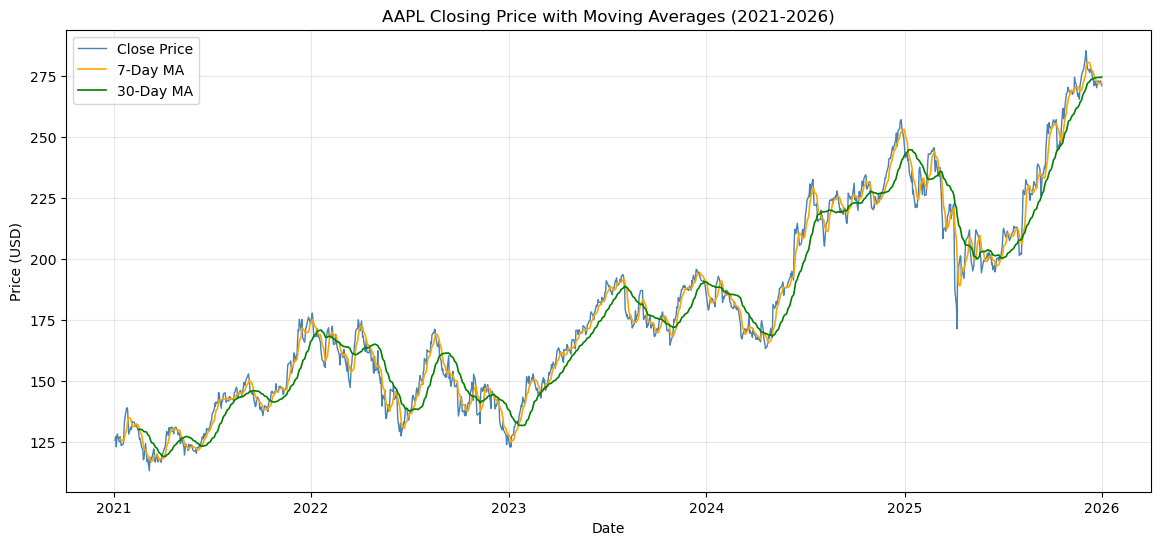

In [24]:
plt.figure(figsize=(14,6))
plt.plot(data.index,data["Close"], label ="Close Price", color = "steelblue", linewidth=1)
plt.plot(data.index, data["MA7"], label = "7-Day MA", color = "orange", linewidth=1.2)
plt.plot(data.index, data["MA30"], label = "30-Day MA", color = "green", linewidth=1.2)

plt.title("AAPL Closing Price with Moving Averages (2021-2026)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Trading Volume Trend Chart

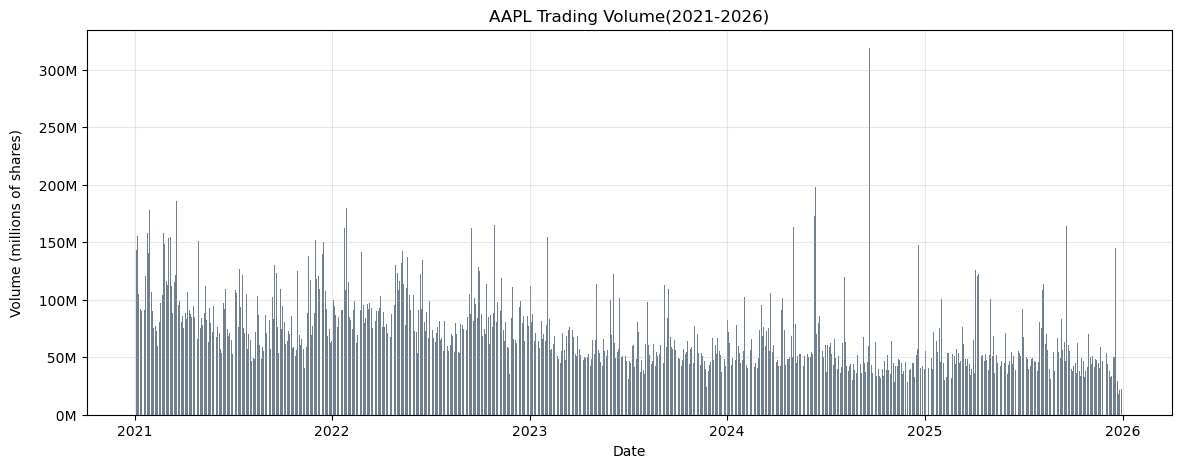

In [25]:
plt.figure(figsize=(14,5))
plt.bar(data.index, data["Volume"], color="slategray", width=1)

plt.title("AAPL Trading Volume(2021-2026)")
plt.xlabel("Date")
plt.ylabel("Volume (millions of shares)")
plt.gca().yaxis.set_major_formatter(lambda x, pos: f" {x/1e6: .0f}M")
plt.grid(alpha=0.3)
plt.show()

##  Daily % Change (Returns) Chart

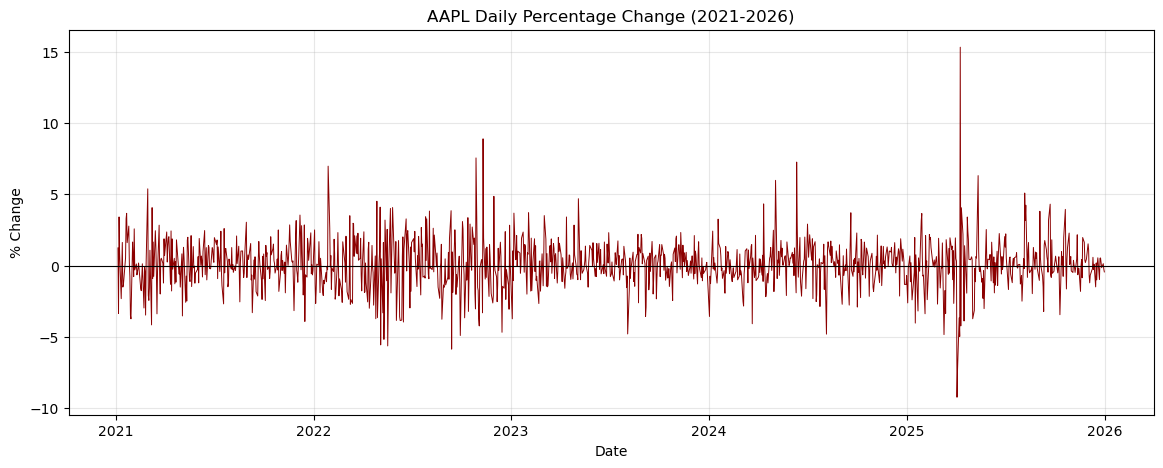

In [26]:
plt.figure(figsize=(14,5))
plt.plot(data.index, data["Pct_Change"], color= "darkred", linewidth=0.7)

plt.title("AAPL Daily Percentage Change (2021-2026)")
plt.xlabel("Date")
plt.ylabel("% Change")
plt.axhline(0, color="black", linewidth=0.8)
plt.grid(alpha=0.3)
plt.show()

## Monthly Returns Chart

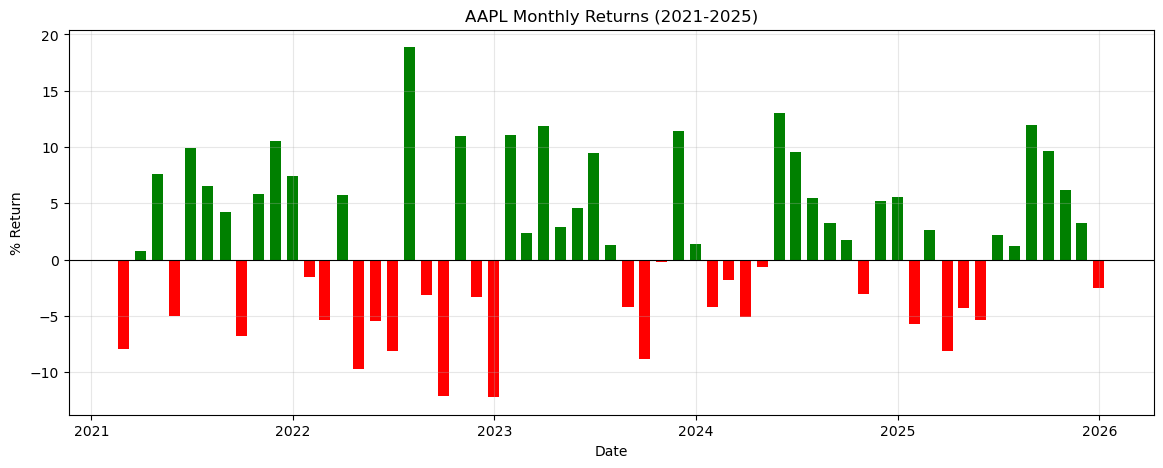

In [27]:
plt.figure(figsize=(14,5))
colors = ["green" if x > 0 else "red" for x in Monthly_returns]
plt.bar(Monthly_returns.index, Monthly_returns, color=colors, width=20)

plt.title("AAPL Monthly Returns (2021-2025)")
plt.xlabel("Date")
plt.ylabel("% Return")
plt.axhline(0, color="black", linewidth=0.8)
plt.grid(alpha=0.3)
plt.show()